# Benchmarking YOLO models on count-labelled images

Benchmark several YOLO models on a count-labelled image set.

Ground truth = per-image object COUNTS for a few categories (no boxes),
so accuracy is measured with count-error metrics, not mAP/IoU.

For each model the script:
  1. warms up the model (excluded from timing),
  2. runs inference ONCE per image at a very low confidence threshold and
     caches the confidence of every detection per category,
  3. derives counts for any confidence threshold from that cache, so a
     threshold sweep costs no extra GPU time,
  4. reports latency and per-category accuracy metrics.

Outputs (in OUTPUT_DIR):
  predictions_<model>.csv   per-image predicted vs true counts (at BASE_CONF)
  summary.csv               one row per model: latency + accuracy
  per_category.csv          one row per model x category
  conf_sweep.csv            metrics vs confidence threshold (if enabled)

## Setup

Run once per Colab session. Skip the Drive mount if your data is local.

In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Copying to local scratch is much faster than reading from Drive.
!cp -r "/content/drive/MyDrive/datasets/Computer_Vision_Project/test_1" \
        "/content/local_video_stills"

!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [4]:
import time
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Configuration

In [5]:
IMAGE_DIR = "/content/local_video_stills"
LABELS_CSV = "/content/drive/MyDrive/datasets/results2_reviewed.csv"
OUTPUT_DIR = "/content/drive/MyDrive/datasets/benchmark_SMOKE"

MODELS = [
    "yolov8n.pt",
    "yolov8s.pt",
    "yolo11n.pt",
    "yolo11s.pt",
    "yolo26n.pt",
   # "yolo26m.pt",
    "yolo26s.pt",
    "yolo26x.pt"
]

# Model class names (COCO) -> label column in your CSV.
CATEGORY_MAP = {
    "bicycle": "bicycle",
    "car": "car",
    "traffic light": "traffic light",
}
CATEGORIES = list(CATEGORY_MAP.keys())          # model-side names
LABEL_COLS = list(CATEGORY_MAP.values())        # csv-side names

FILENAME_COL = "filename"     # column in LABELS_CSV holding the image name

DEVICE = "cuda"               # "cuda", "cpu", or 0
IMGSZ = 640
HALF = True                   # fp16; set False on CPU
BASE_CONF = 0.25              # threshold used for the headline numbers
IOU_NMS = 0.7
MAX_IMAGES = 600             # e.g. 500 to cap the run
WARMUP_RUNS = 5

# Confidence sweep (free — reuses cached detections)
RUN_CONF_SWEEP = True
SWEEP_THRESHOLDS = [round(x, 2) for x in np.arange(0.05, 0.91, 0.05)]

# Inference is always run at this floor so the sweep has data to work with.
CAPTURE_CONF = min(0.01, min(SWEEP_THRESHOLDS) if RUN_CONF_SWEEP else BASE_CONF)

VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

## 2. Ground truth

In [6]:
REVIEW_COL = "review_status"
ACCEPTED_STATUS = {"confirmed", "corrected"}   # set to None to disable filtering
#ACCEPTED_STATUS = None   # set to None to disable filtering

def load_ground_truth(csv_path):
    df = pd.read_csv(csv_path)
    if ACCEPTED_STATUS and REVIEW_COL in df.columns:
        before = len(df)
        df = df[df[REVIEW_COL].isin(ACCEPTED_STATUS)].copy()
        print(f"Ground truth: kept {len(df)}/{before} human-reviewed rows.")
    missing = [c for c in [FILENAME_COL] + LABEL_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}. Found: {list(df.columns)}")
    df = df[[FILENAME_COL] + LABEL_COLS].copy()
    df["_key"] = df[FILENAME_COL].astype(str).map(lambda s: Path(s).name.lower())
    df[LABEL_COLS] = df[LABEL_COLS].fillna(0).astype(int)
    return df.set_index("_key")

In [7]:
def load_ground_truth(csv_path):
    df = pd.read_csv(csv_path)
    missing = [c for c in [FILENAME_COL] + LABEL_COLS if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns in {csv_path}: {missing}. Found: {list(df.columns)}"
        )
    df = df[[FILENAME_COL] + LABEL_COLS].copy()
    # match on basename, case-insensitive, to survive path/casing differences
    df["_key"] = df[FILENAME_COL].astype(str).map(lambda s: Path(s).name.lower())
    df[LABEL_COLS] = df[LABEL_COLS].fillna(0).astype(int)
    return df.set_index("_key")

In [8]:
def collect_images(image_dir, gt):
    paths = sorted(
        p for p in Path(image_dir).iterdir()
        if p.suffix.lower() in VALID_EXT and p.name.lower() in gt.index
    )
    if MAX_IMAGES:
        paths = paths[:MAX_IMAGES]
    if not paths:
        raise RuntimeError(
            f"No labelled images found in {image_dir}. "
            "Check that filenames in the CSV match the files on disk."
        )
    return paths

## 3. Inference pass (one per model)

In [9]:
def run_model(weights, image_paths):
    """Returns (detections, timing) where detections[i][cat] = list of confs."""
    model = YOLO(weights)
    name_to_id = {v: k for k, v in model.names.items()}
    wanted_ids = {}
    for cat in CATEGORIES:
        if cat not in name_to_id:
            raise ValueError(f"'{cat}' is not a class of {weights}: {list(model.names.values())[:10]}...")
        wanted_ids[name_to_id[cat]] = cat

    # ---- warm-up (CUDA context, cudnn autotune, fp16 kernels) ----
    for _ in range(WARMUP_RUNS):
        model.predict(str(image_paths[0]), device=DEVICE, imgsz=IMGSZ,
                      half=HALF, conf=CAPTURE_CONF, iou=IOU_NMS, verbose=False)

    detections = []
    engine_ms, pre_ms, post_ms, wall_ms = [], [], [], []

    for p in image_paths:
        t0 = time.perf_counter()
        r = model.predict(str(p), device=DEVICE, imgsz=IMGSZ, half=HALF,
                          conf=CAPTURE_CONF, iou=IOU_NMS, verbose=False)[0]
        wall_ms.append((time.perf_counter() - t0) * 1000.0)

        engine_ms.append(r.speed["inference"])
        pre_ms.append(r.speed["preprocess"])
        post_ms.append(r.speed["postprocess"])

        per_cat = defaultdict(list)
        if r.boxes is not None and len(r.boxes):
            cls = r.boxes.cls.cpu().numpy().astype(int)
            conf = r.boxes.conf.cpu().numpy().astype(float)
            for c, s in zip(cls, conf):
                if c in wanted_ids:
                    per_cat[wanted_ids[c]].append(s)
        detections.append(per_cat)

    timing = {
        "inference_ms_mean": float(np.mean(engine_ms)),
        "inference_ms_median": float(np.median(engine_ms)),
        "inference_ms_p95": float(np.percentile(engine_ms, 95)),
        "preprocess_ms_mean": float(np.mean(pre_ms)),
        "postprocess_ms_mean": float(np.mean(post_ms)),
        "end_to_end_ms_mean": float(np.mean(wall_ms)),
        "fps_end_to_end": 1000.0 / float(np.mean(wall_ms)),
    }
    return detections, timing

In [10]:
def counts_at(detections, threshold):
    """Cached confidences -> count matrix (n_images x n_categories)."""
    return np.array(
        [[int(sum(1 for s in d.get(cat, []) if s >= threshold)) for cat in CATEGORIES]
         for d in detections],
        dtype=int,
    )

## 4. Accuracy metrics

In [11]:
def category_metrics(y_true, y_pred):
    err = y_pred - y_true
    abs_err = np.abs(err)
    denom = y_true.sum()
    with np.errstate(invalid="ignore"):
        corr = (np.corrcoef(y_true, y_pred)[0, 1]
                if y_true.std() > 0 and y_pred.std() > 0 else np.nan)
    return {
        "mae": abs_err.mean(),
        "rmse": float(np.sqrt((err ** 2).mean())),
        "bias": err.mean(),                     # >0 = over-counting
        "exact_match": (abs_err == 0).mean(),
        "within_1": (abs_err <= 1).mean(),
        "count_accuracy": 1.0 - abs_err.sum() / denom if denom else np.nan,
        "total_true": int(y_true.sum()),
        "total_pred": int(y_pred.sum()),
        "pearson_r": corr,
    }

In [12]:
def evaluate(gt_matrix, pred_matrix):
    per_cat = {CATEGORIES[i]: category_metrics(gt_matrix[:, i], pred_matrix[:, i])
               for i in range(len(CATEGORIES))}
    overall = {
        "macro_mae": float(np.mean([m["mae"] for m in per_cat.values()])),
        "macro_rmse": float(np.mean([m["rmse"] for m in per_cat.values()])),
        "macro_count_accuracy": float(np.nanmean([m["count_accuracy"] for m in per_cat.values()])),
        "all_categories_exact": float(np.mean(np.all(gt_matrix == pred_matrix, axis=1))),
    }
    return per_cat, overall

## 5. Main

In [13]:
def main():
    out = Path(OUTPUT_DIR)
    out.mkdir(parents=True, exist_ok=True)

    gt = load_ground_truth(LABELS_CSV)
    image_paths = collect_images(IMAGE_DIR, gt)
    gt_matrix = np.array(
        [[gt.loc[p.name.lower(), CATEGORY_MAP[c]] for c in CATEGORIES] for p in image_paths],
        dtype=int,
    )
    print(f"Benchmarking {len(MODELS)} models on {len(image_paths)} labelled images.\n")

    summary_rows, per_cat_rows, sweep_rows = [], [], []

    for weights in MODELS:
        tag = Path(weights).stem
        print(f"--- {tag} ---")
        detections, timing = run_model(weights, image_paths)

        preds = counts_at(detections, BASE_CONF)
        per_cat, overall = evaluate(gt_matrix, preds)

        # per-image dump
        pred_df = pd.DataFrame(preds, columns=[f"pred_{c}" for c in LABEL_COLS])
        true_df = pd.DataFrame(gt_matrix, columns=[f"true_{c}" for c in LABEL_COLS])
        pd.concat(
            [pd.DataFrame({"filename": [p.name for p in image_paths]}), true_df, pred_df],
            axis=1,
        ).to_csv(out / f"predictions_{tag}.csv", index=False)

        summary_rows.append({"model": tag, "conf": BASE_CONF, **timing, **overall})
        for cat, m in per_cat.items():
            per_cat_rows.append({"model": tag, "category": cat, **m})

        print(f"  inference {timing['inference_ms_mean']:.2f} ms  |  "
              f"end-to-end {timing['end_to_end_ms_mean']:.2f} ms  |  "
              f"macro MAE {overall['macro_mae']:.3f}")
        for cat, m in per_cat.items():
            print(f"    {cat:<14} MAE {m['mae']:.3f}  bias {m['bias']:+.3f}  "
                  f"exact {m['exact_match']:.1%}")

        if RUN_CONF_SWEEP:
            for thr in SWEEP_THRESHOLDS:
                p = counts_at(detections, thr)
                pc, ov = evaluate(gt_matrix, p)
                row = {"model": tag, "conf": thr, **ov}
                for cat, m in pc.items():
                    row[f"{cat}_mae"] = m["mae"]
                    row[f"{cat}_bias"] = m["bias"]
                sweep_rows.append(row)
            best = min((r for r in sweep_rows if r["model"] == tag),
                       key=lambda r: r["macro_mae"])
            print(f"  best conf = {best['conf']:.2f} (macro MAE {best['macro_mae']:.3f})")
        print()

    summary = pd.DataFrame(summary_rows).sort_values("macro_mae")
    summary.to_csv(out / "summary.csv", index=False)
    pd.DataFrame(per_cat_rows).to_csv(out / "per_category.csv", index=False)
    if sweep_rows:
        pd.DataFrame(sweep_rows).to_csv(out / "conf_sweep.csv", index=False)

    print("=" * 70)
    print(summary[["model", "inference_ms_mean", "end_to_end_ms_mean",
                   "macro_mae", "macro_count_accuracy"]].to_string(index=False))
    print("=" * 70)
    print(f"\nWritten to {out}")

    (out / "run_config.json").write_text(json.dumps({
        "models": MODELS, "imgsz": IMGSZ, "half": HALF, "device": DEVICE,
        "base_conf": BASE_CONF, "iou": IOU_NMS, "n_images": len(image_paths),
    }, indent=2))

In [14]:
from pathlib import Path
import pandas as pd

gt_raw = pd.read_csv(LABELS_CSV)
print("rows:", len(gt_raw), "| columns:", list(gt_raw.columns))
print("\nreview_status values (repr, to expose whitespace/case):")
print(gt_raw["review_status"].astype(str).str.strip().value_counts().to_string())
print("\nACCEPTED_STATUS is currently:", repr(ACCEPTED_STATUS))

csv_names = set(gt_raw["filename"].astype(str).map(lambda s: Path(s).name.lower()))
print("\noverlap with each candidate image folder:")
for d in ["/content/local_video_stills", "/content/local_video_stills2",
          "/content/local_video_stills3"]:
    p = Path(d)
    if not p.exists():
        print(f"  {d:38} (missing)")
        continue
    disk = {f.name.lower() for f in p.iterdir() if f.suffix.lower() in VALID_EXT}
    print(f"  {d:38} {len(disk):5} images, {len(csv_names & disk):5} matched")

rows: 1001 | columns: ['filename', 'person', 'bicycle', 'motorcycle', 'car', 'traffic light', 'timestamp', 'review_status']

review_status values (repr, to expose whitespace/case):
review_status
confirmed       479
not_reviewed    400
corrected       122

ACCEPTED_STATUS is currently: {'confirmed', 'corrected'}

overlap with each candidate image folder:
  /content/local_video_stills             1001 images,  1001 matched
  /content/local_video_stills2           (missing)
  /content/local_video_stills3           (missing)


## Run

In [15]:
main()

Benchmarking 7 models on 600 labelled images.

--- yolov8n ---
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprec

## Inspect the results

`summary` is sorted by macro MAE. Latency and accuracy usually disagree — plot them against each other to see the Pareto front.

In [16]:
summary = pd.read_csv(f'{OUTPUT_DIR}/summary.csv')
summary[['model', 'inference_ms_mean', 'end_to_end_ms_mean',
         'macro_mae', 'macro_count_accuracy']]

,model,inference_ms_mean,end_to_end_ms_mean,macro_mae,macro_count_accuracy
0,yolo26x,19.592186,42.088798,0.186111,0.561578
1,yolo11s,10.015557,31.645631,0.248889,0.460126
2,yolo26s,12.265825,33.642007,0.262778,0.390391
3,yolov8s,7.607256,28.837151,0.262778,0.416918
4,yolo11n,10.504460,32.888542,0.305000,0.308714
5,yolov8n,7.527603,28.706803,0.327222,0.242556
6,yolo26n,12.846473,35.233691,0.352222,0.238710


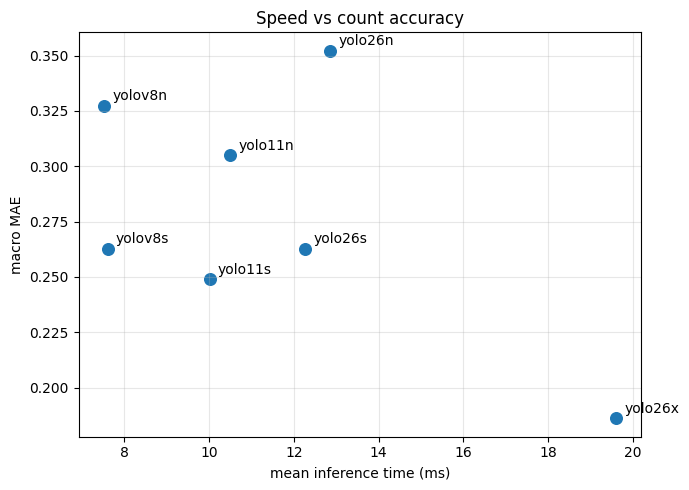

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(summary['inference_ms_mean'], summary['macro_mae'], s=70)
for _, r in summary.iterrows():
    ax.annotate(r['model'], (r['inference_ms_mean'], r['macro_mae']),
                textcoords='offset points', xytext=(6, 4))
ax.set_xlabel('mean inference time (ms)')
ax.set_ylabel('macro MAE')
ax.set_title('Speed vs count accuracy')
ax.grid(alpha=0.3)
plt.tight_layout()

In [18]:
# Per-category breakdown: bias sign tells you over- vs under-counting.
per_cat = pd.read_csv(f'{OUTPUT_DIR}/per_category.csv')
per_cat.pivot(index='model', columns='category',
              values=['mae', 'bias', 'exact_match']).round(3)

mae                         bias                       \
category bicycle    car traffic light bicycle    car traffic light   
model                                                                
yolo11n    0.192  0.645         0.078  -0.185 -0.575        -0.055   
yolo11s    0.142  0.543         0.062  -0.132 -0.457        -0.015   
yolo26n    0.210  0.763         0.083  -0.210 -0.747        -0.070   
yolo26s    0.170  0.548         0.070  -0.157 -0.498        -0.050   
yolo26x    0.120  0.387         0.052  -0.097 -0.320        -0.035   
yolov8n    0.207  0.687         0.088  -0.207 -0.630        -0.048   
yolov8s    0.172  0.555         0.062  -0.148 -0.442        -0.045   

         exact_match                       
category     bicycle    car traffic light  
model                                      
yolo11n        0.873  0.690         0.960  
yolo11s        0.887  0.715         0.957  
yolo26n        0.867  0.683         0.962  
yolo26s        0.878  0.725         0.965  
yolo26x        0.903  0.760         0.970  
yolov8n        0.868  0.680         0.952  
yolov8s        0.880  0.718         0.963

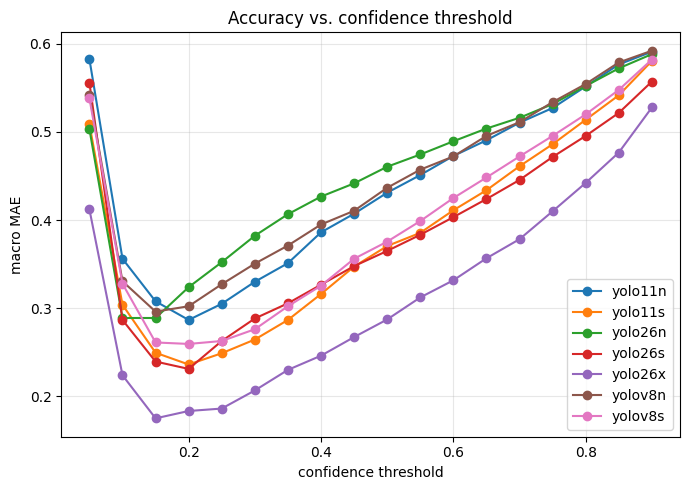

In [22]:
# How sensitive is each model to the confidence threshold?
sweep = pd.read_csv(f'{OUTPUT_DIR}/conf_sweep.csv')
fig, ax = plt.subplots(figsize=(7, 5))
for m, g in sweep.groupby('model'):
    ax.plot(g['conf'], g['macro_mae'], marker='o', label=m)
ax.set_xlabel('confidence threshold'); ax.set_ylabel('macro MAE')
ax.set_title('Accuracy vs. confidence threshold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

In [20]:
# Best threshold per model
sweep.loc[sweep.groupby('model')['macro_mae'].idxmin()][
    ['model', 'conf', 'macro_mae', 'macro_count_accuracy']]

,model,conf,macro_mae,macro_count_accuracy
39,yolo11n,0.20,0.286667,0.319283
57,yolo11s,0.20,0.236111,0.463208
73,yolo26n,0.10,0.288889,0.285618
93,yolo26s,0.20,0.231111,0.428947
110,yolo26x,0.15,0.175000,0.544673
2,yolov8n,0.15,0.296111,0.233423
21,yolov8s,0.20,0.259444,0.413525
